<h2 style="
  background: linear-gradient(135deg, #0f2027, #203a43, #2c5364);
  font-family: 'Poppins', sans-serif;
  display: inline-block;
  padding: 16px 40px;
  margin: 30px auto;
  border-radius: 14px;
  color: #ffe066;
  font-size: 2rem;
  font-weight: 700;
  letter-spacing: 2px;
  text-align: center;
  box-shadow: 0 6px 20px rgba(0,0,0,0.35);
  text-transform: uppercase;
">
  Superstore Sales Performance Analysis
</h2>

<div style="
  font-family: 'Poppins', sans-serif;
  text-align: center;
  font-size: 1.05rem;
  color: white;
  margin-top: -12px;
  padding: 8px 190px;
  display: inline-block;
  border-radius: 10px;
  background: #2c5364;
  border-left: 5px solid #ffe066;
  border-right: 5px solid #ffe066;
  font-weight: 600;
  box-shadow: 0 6px 25px rgba(0,0,0,0.35);
">
  Prepared for: Future Interns – Data Science & Analytics Internship  
</div>


-------------------------------------

## 📘 Project Overview

The purpose of this project is to analyze sales performance using the Superstore dataset and uncover meaningful business insights that can drive strategic decisions.  
Instead of simply creating charts, this analysis focuses on understanding **what the data is telling about the business**, identifying growth opportunities, and highlighting areas that require improvement.

Through this project, we aim to:

- Understand which products and categories contribute most to revenue and profit  
- Analyze sales trends over time to identify seasonality and growth patterns  
- Compare the performance of customer segments and geographic regions  
- Discover hidden opportunities that can help the business grow faster  
- Present insights in a dashboard format suitable for stakeholders and decision-makers  

This analysis simulates a real-world business scenario where data is used to answer critical questions and support data-driven decision making.

The insights derived here will help the business improve profitability, optimize product performance, and strengthen overall sales strategy.


In [134]:
#importing Python library which will I use in this notebook.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#calling file with help of pandas
t1 = pd.read_csv(r"C:\Users\ACER\Downloads\DATA_RAW\Sample - Superstore.csv", encoding="cp1252")

In [3]:
t1.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [4]:
# We use info() method to see more information of our train dataset.
t1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
t1.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [6]:
print("Here we can see Rows and Columns",t1.shape)

Here we can see Rows and Columns (9994, 21)


In [7]:
## checking if any column has some missing values
t1.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
#show the descriptive statistics of data types
t1.describe().round(2)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


In [9]:
#describe(include = ['O'])* will show the descriptive statistics of object data types.
t1.describe(include=['O'])

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,09-05-2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


In [10]:
t1.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [11]:
# t1.columns = t1.columns.str.strip().str.replace(" ","_").str.lower()

In [12]:
t1.sample()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2872,2873,CA-2017-135167,6/15/2017,6/20/2017,Standard Class,SC-20800,Stuart Calhoun,Consumer,United States,Los Angeles,...,90036,West,OFF-AR-10002399,Office Supplies,Art,"Dixon Prang Watercolor Pencils, 10-Color Set w...",4.26,1,0.0,1.7466


In [13]:
#t1.groupby("Category")["Sales"].sum().plot(kind="bar", title="Sales by Category")

### **1️⃣ Which products generate the most revenue?**

To answer this, we will:
- Calculate revenue per product  
- Identify top 10 highest revenue products  
- Find slow-moving or under-performing products  
- Compare product profitability
- ------------------------------

In [14]:
t1.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


In [58]:
#Calculate revenue per product
# Revenue per product
t1.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [55]:
# Aggregate sales, quantity, and profit per product
t1.groupby("Product Name").agg({
    "Sales": "sum",
    "Quantity": "sum",
    "Profit": "sum"
}).sort_values(by="Sales", ascending=True).head(10)

,Sales,Quantity,Profit
Product Name,,,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.624,2,-4.4660
Avery 5,5.760,2,2.8224
Xerox 20,6.480,1,3.1104
Grip Seal Envelopes,7.072,2,2.3868
Avery Hi-Liter Pen Style Six-Color Fluorescent Set,7.700,2,3.1570
"Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink",7.800,4,3.0420
Xerox 1989,7.968,2,2.6892
4009 Highlighters,8.040,6,2.7336
Stockwell Gold Paper Clips,8.096,5,3.4040


In [53]:
# Find products with low sales and low quantity
product_perf[(product_perf["Sales"] < product_perf["Sales"].quantile(0.2)) &
                           (product_perf["Quantity"] < product_perf["Quantity"].quantile(0.2))]



,Sales,Quantity,Profit
Product Name,,,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.624,2,-4.4660
Avery 5,5.760,2,2.8224
Xerox 20,6.480,1,3.1104
Grip Seal Envelopes,7.072,2,2.3868
Avery Hi-Liter Pen Style Six-Color Fluorescent Set,7.700,2,3.1570
...,...,...,...
Fiskars Spring-Action Scissors,75.492,6,13.4208
"Geographics Note Cards, Blank, White, 8 1/2"" x 11""",76.092,8,29.5416
Eldon File Chest Portable File,79.400,5,5.9550


--------------------
### **2️⃣ How do sales change over time?**

We will analyze:
- Monthly and yearly sales trends  
- Seasonality patterns  
- Monthly profit trends  
- Growth after promotions/discounts  
---


In [19]:
t1.sample()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
8401,8402,CA-2015-110814,12-05-2015,12-09-2015,Second Class,BD-11635,Brian Derr,Consumer,United States,New York City,...,10009,East,FUR-CH-10003535,Furniture,Chairs,"Global Armless Task Chair, Royal Blue",164.646,3,0.1,12.8058


In [20]:
# Convert to datetime
t1['Date'] = pd.to_datetime(t1['Order Date'], format='mixed', dayfirst=False)


In [21]:
t1['Year'] = t1['Date'].dt.year

In [22]:
t1['month'] = t1['Date'].dt.month

In [23]:
t1.sample()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Date,Year,month
1501,1502,CA-2017-130386,11-12-2017,11/18/2017,Standard Class,NG-18430,Nathan Gelder,Consumer,United States,Austin,...,Office Supplies,Storage,Tennsco Double-Tier Lockers,540.048,3,0.2,-47.2542,2017-11-12,2017,11


In [24]:
print(t1[['Order Date','Date','Year']].head())

   Order Date       Date  Year
0  11-08-2016 2016-11-08  2016
1  11-08-2016 2016-11-08  2016
2  06-12-2016 2016-06-12  2016
3  10-11-2015 2015-10-11  2015
4  10-11-2015 2015-10-11  2015


In [25]:
#Monthly and yearly sales trends


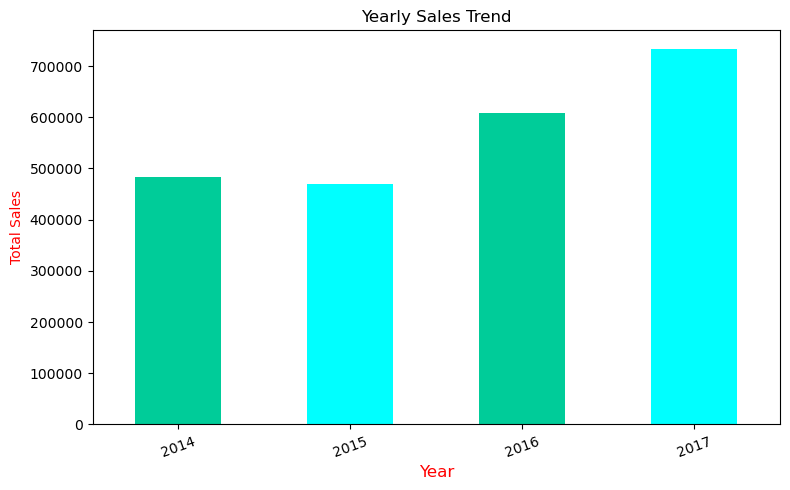

In [26]:
yearly_sales = t1.groupby('Year')['Sales'].sum()

import matplotlib.pyplot as plt
yearly_sales.plot(kind='bar', figsize=(8,5), color=['#00CC99','Aqua'], title="Yearly Sales Trend")
plt.ylabel("Total Sales", color='Red')
plt.xlabel("Year", color='Red', fontsize= 12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

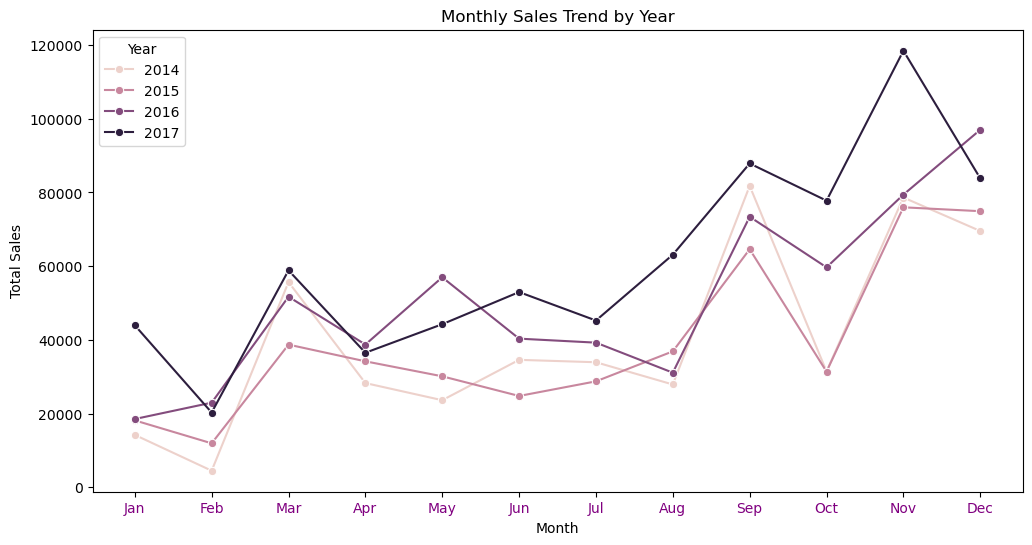

In [27]:
monthly_year_sales = t1.groupby(['Year','month'])['Sales'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_year_sales, x='month', y='Sales', hue='Year', marker='o')
plt.title("Monthly Sales Trend by Year")
plt.xticks(range(1,13), 
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], color='Purple')
plt.ylabel("Total Sales")
plt.xlabel("Month")
plt.show()

--------------------
### **3️⃣ Which categories or regions are most profitable?**

We will break down:
- Category-wise revenue and profit  
- Sub-category performance  
- Region-wise sales comparison  
- Profit margin analysis
- ----------------  

In [28]:
t1.sample()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Date,Year,month
941,942,CA-2016-142958,12/13/2016,12/20/2016,Standard Class,RW-19630,Rob Williams,Corporate,United States,Torrance,...,Office Supplies,Binders,"Acco Pressboard Covers with Storage Hooks, 14 ...",6.096,2,0.2,2.2098,2016-12-13,2016,12


In [46]:
# Sales and profit per category
t1.groupby("Category").agg({
    "Sales": "sum",
    "Profit": "mean",
    "Quantity": "max"
})

,Sales,Profit,Quantity
Category,,,
Furniture,741999.7953,8.699327,14
Office Supplies,719047.0320,20.327050,14
Technology,836154.0330,78.752002,14


In [31]:
Category_Sales = t1.groupby('Category')['Profit'].sum()

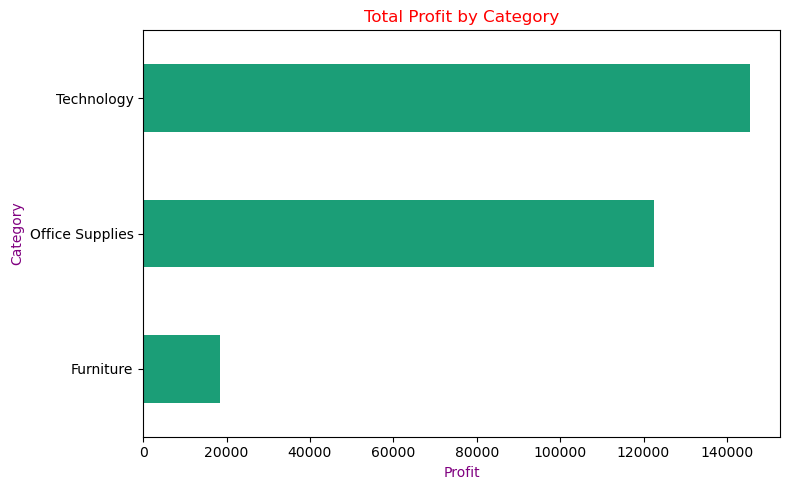

In [32]:
Category_Sales.plot(kind='barh', colormap='Dark2', figsize=(8,5))
plt.title("Total Profit by Category", color='red')
plt.xlabel("Profit", color='purple')
plt.ylabel("Category", color='purple')
plt.tight_layout()
plt.show()


In [52]:
#Sub-category performance
t1.groupby("Sub-Category").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Quantity": "sum"
}).reset_index().head(10)


,Sub-Category,Sales,Profit,Quantity
0,Accessories,167380.3180,41936.6357,2976
1,Appliances,107532.1610,18138.0054,1729
2,Art,27118.7920,6527.7870,3000
3,Binders,203412.7330,30221.7633,5974
4,Bookcases,114879.9963,-3472.5560,868
5,Chairs,328449.1030,26590.1663,2356
6,Copiers,149528.0300,55617.8249,234
7,Envelopes,16476.4020,6964.1767,906
8,Fasteners,3024.2800,949.5182,914
9,Furnishings,91705.1640,13059.1436,3563


In [63]:
t1.sample(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Date,Year,month
9890,9891,US-2016-115441,7/25/2016,7/28/2016,Second Class,SH-19975,Sally Hughsby,Corporate,United States,Milwaukee,...,Office Supplies,Paper,"Speediset Carbonless Redi-Letter 7"" x 8 1/2""",20.62,2,0.0,9.6914,2016-07-25,2016,7


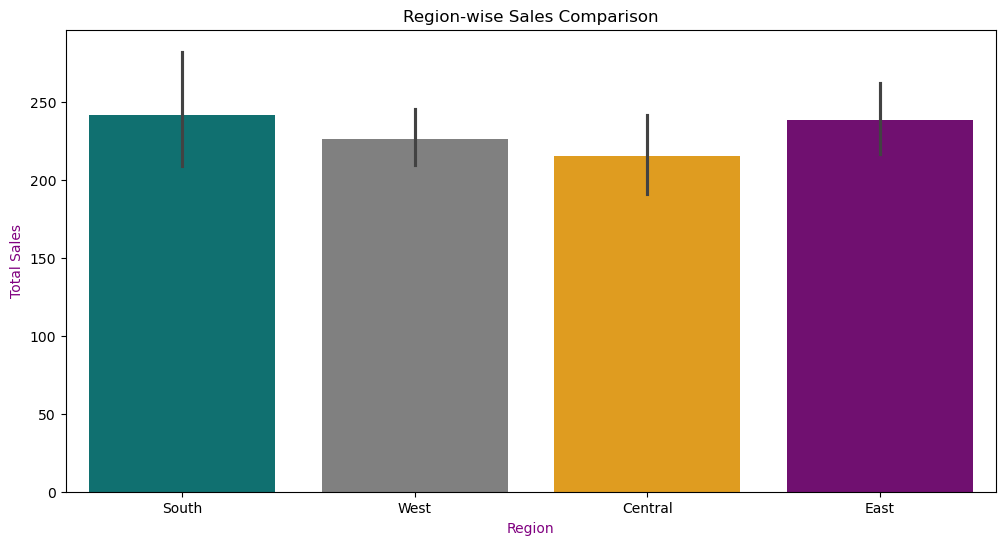

In [92]:
plt.figure(figsize=(12,6))
sns.barplot(x='Region', y='Sales', data=t1, hue='Region', palette=['teal','grey','orange','purple'], legend=False)

plt.title("Region-wise Sales Comparison")
plt.ylabel("Total Sales", color='Purple')
plt.xlabel("Region", color='Purple')
plt.show()


In [85]:
# Aggregate sales and profit by category or sub-category
margin_perf = t1.groupby("Category").agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

In [86]:
# Calculate margin %
margin_perf["profit_margin"] = (margin_perf["Profit"] / margin_perf["Sales"]) * 100
print(margin_perf)

          Category        Sales       Profit  profit_margin
0        Furniture  741999.7953   18451.2728       2.486695
1  Office Supplies  719047.0320  122490.8008      17.035158
2       Technology  836154.0330  145454.9481      17.395712


-------------
### **4️⃣ Where should the business focus to grow faster?**

This is the actionable part of the analysis.  
We will identify:
- Most profitable categories  
- Fastest-growing products  
- High-potential regions  
- Loss-making areas that need optimization
- ---------------------- 

In [101]:
#Most profitable categories
print("These Category are most profitable \n\n",
    t1.groupby("Category").agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index())

These Category are most profitable 

           Category        Sales       Profit
0        Furniture  741999.7953   18451.2728
1  Office Supplies  719047.0320  122490.8008
2       Technology  836154.0330  145454.9481


In [102]:
t1.sample()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Date,Year,month
3150,3151,CA-2015-147830,12/15/2015,12/18/2015,First Class,NF-18385,Natalie Fritzler,Consumer,United States,Newark,...,Technology,Accessories,Plantronics Savi W720 Multi-Device Wireless He...,2025.36,6,0.2,607.608,2015-12-15,2015,12


In [111]:
t1['Year'].max()

2017

In [107]:
product_year_sales = t1.groupby(['Product Name','Year'])['Sales'].sum().reset_index()

In [112]:
# Pivot to compare year-over-year sales
pivot_sales = product_year_sales.pivot(index='Product Name', columns='Year', values='Sales').fillna(0)

# Calculate growth (latest year vs previous year)
pivot_sales['growth_rate'] = (pivot_sales[2017] - pivot_sales[2016]) / pivot_sales[2016] * 100


In [113]:
fastest_growers = pivot_sales.sort_values('growth_rate', ascending=False).head(10)
print(fastest_growers[['growth_rate']])

Year                                                growth_rate
Product Name                                                   
#10- 4 1/8" x 9 1/2" Recycled Envelopes                     inf
iOttie XL Car Mount                                         inf
"While you Were Out" Message Book, One Form per...          inf
GBC Instant Index System for Binding Systems                inf
GBC Recycled Grain Textured Covers                          inf
GBC Recycled Regency Composition Covers                     inf
GBC Therma-A-Bind 250T Electric Binding System              inf
Fluorescent Highlighters by Dixon                           inf
Global Adaptabilites Bookcase, Cherry/Storm Gra...          inf
Global Comet Stacking Armless Chair                         inf


In [119]:
region_perf = t1.groupby("Region").agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

region_perf["profit_margin"] = (region_perf["Profit"] / region_perf["Sales"]) * 100
print(region_perf)

    Region        Sales       Profit  profit_margin
0  Central  501239.8908   39706.3625       7.921629
1     East  678781.2400   91522.7800      13.483399
2    South  391721.9050   46749.4303      11.934342
3     West  725457.8245  108418.4489      14.944831


C:\Users\ACER\AppData\Local\Temp\ipykernel_24608\1784266244.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_perf, x="Region", y="Sales", palette="Dark2")


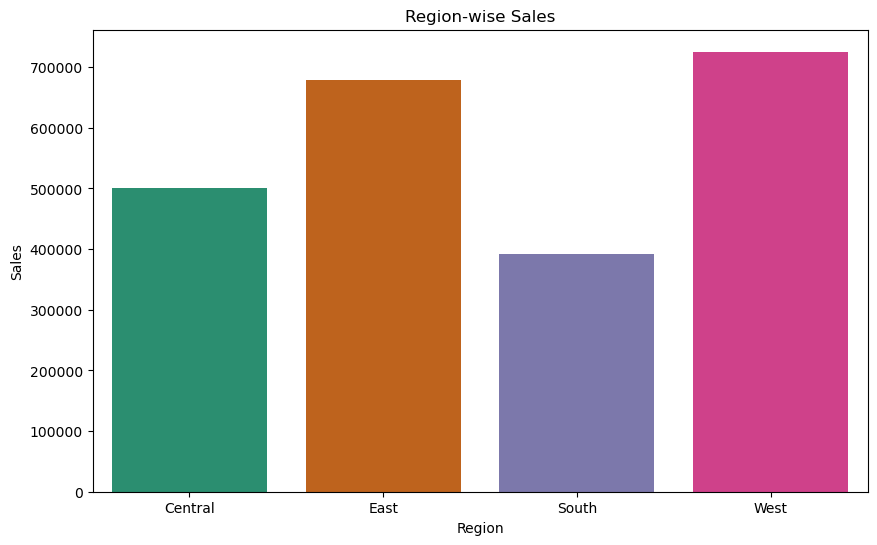

C:\Users\ACER\AppData\Local\Temp\ipykernel_24608\1784266244.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_perf, x="Region", y="profit_margin", palette="coolwarm")


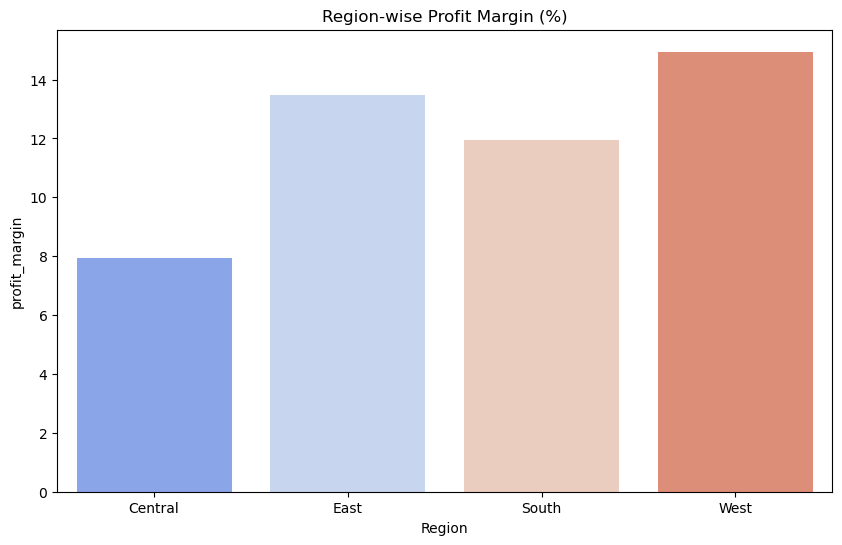

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=region_perf, x="Region", y="Sales", palette="Dark2")
plt.title("Region-wise Sales")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=region_perf, x="Region", y="profit_margin", palette="coolwarm")
plt.title("Region-wise Profit Margin (%)")
plt.show()

In [122]:
t1.sample()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Date,Year,month
2741,2742,CA-2016-165015,2/25/2016,2/27/2016,Second Class,BD-11725,Bruce Degenhardt,Consumer,United States,Newark,...,Office Supplies,Envelopes,Staple envelope,46.72,5,0.2,17.52,2016-02-25,2016,2


In [130]:
t1.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Date',
       'Year', 'month'],
      dtype='object')

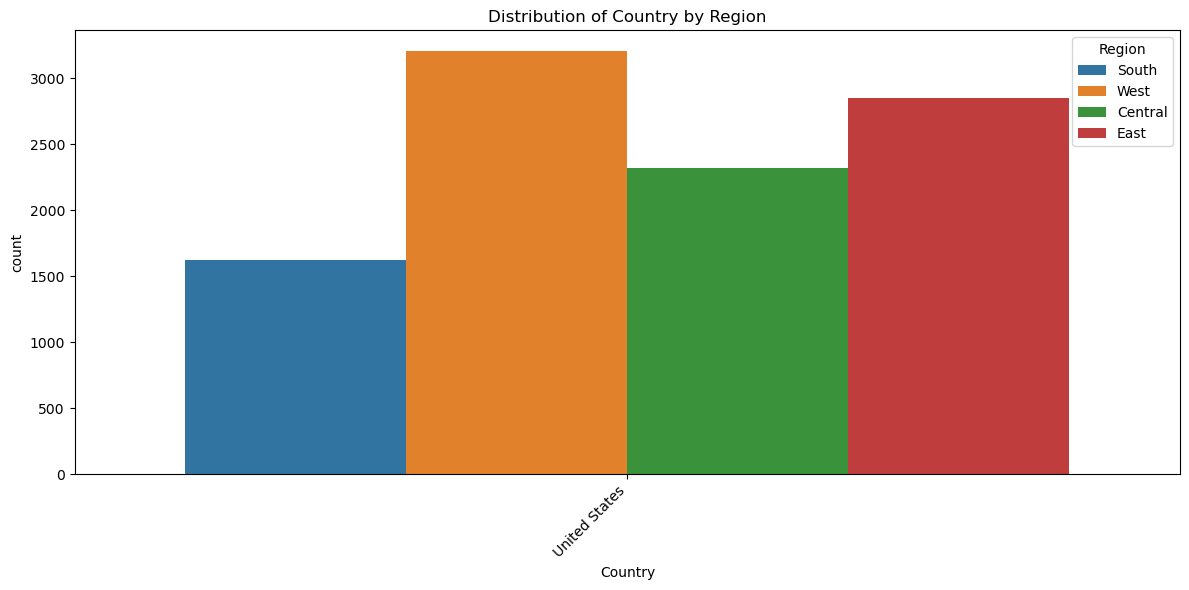

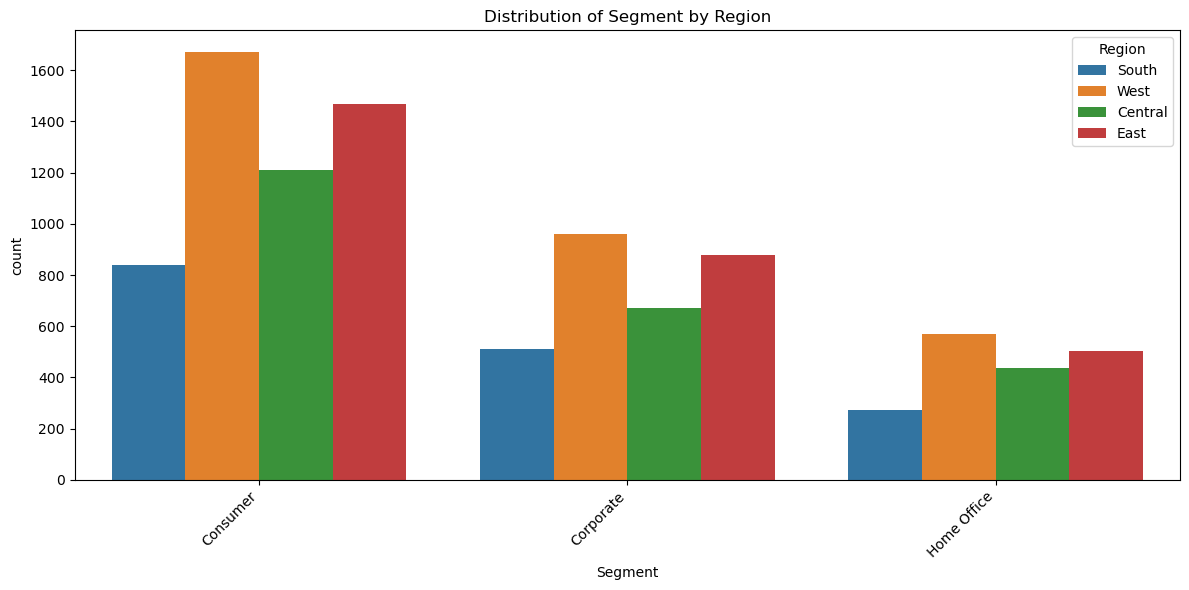

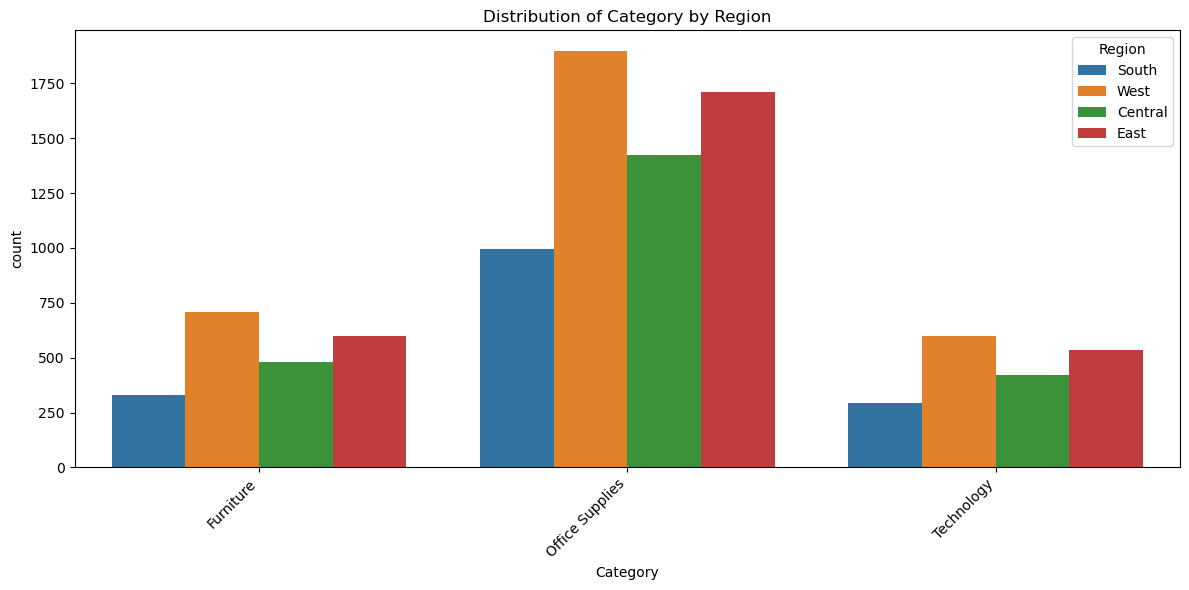

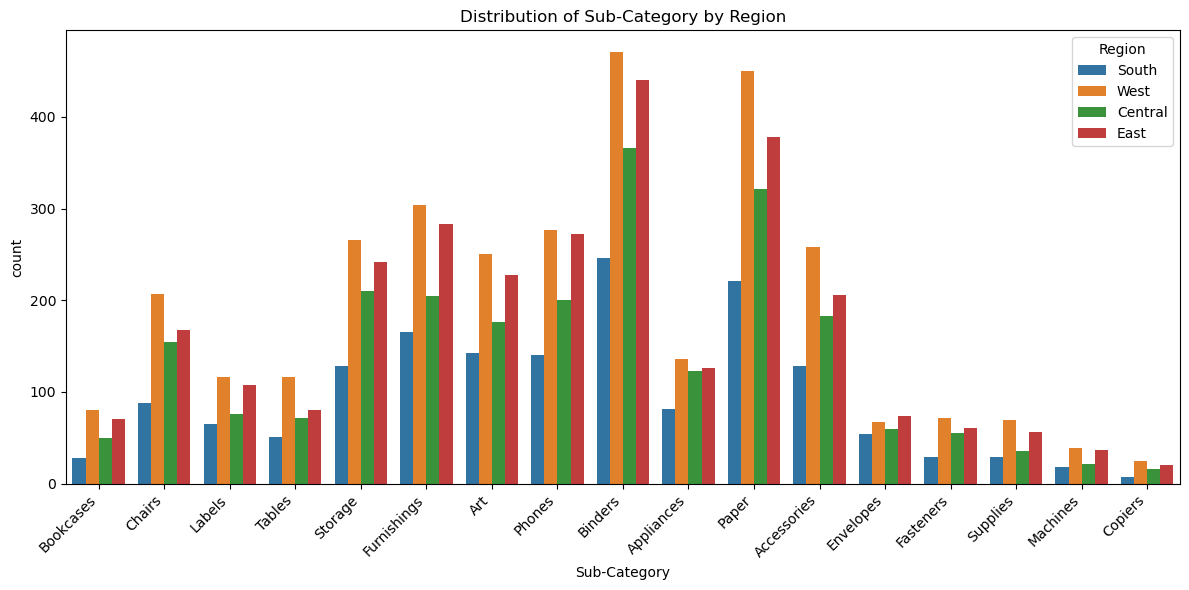

In [132]:
# Choose categorical columns only for countplot
predictors = ['Country', 'Segment','Category', 'Sub-Category']

for i, predictor in enumerate(predictors):
    plt.figure(i, figsize=(12,6))
    sns.countplot(data=t1, x=predictor, hue='Region')
    plt.title(f"Distribution of {predictor} by Region")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


--------------------------------

<h3 style="
  font-family: 'Poppins', sans-serif;
  text-align: center;
  font-size: 1.05rem;
  color: white;
  margin-top: -12px;
  padding: 12px 382px;
  display: inline-block;
  border-radius: 14px;
  background: #2c5364;
  border-left: 5px solid #ffe066;
  border-right: 5px solid #ffe066;
  font-weight: 600;
  box-shadow: 0 6px 25px rgba(0,0,0,0.35);
">
  Analysis done by Vicky Raj
</h3>


--------------------------------